# Quantium — Chip Category Analysis
## Task 1: Customer Analytics

---

## Executive Summary
Analysis of 246,740 chip transactions across 71,287 customers reveals that
**Mainstream Young Singles/Couples** and **Budget Older Families** are the 
highest value customer segments. Mainstream customers drive the most revenue
overall at $700,865 — significantly ahead of Premium customers at $472,905.

---

## Data Overview
- **Transactions dataset:** 264,836 rows cleaned to 246,740 after removing 
  non-chip products
- **Customer dataset:** 72,637 unique customers across 7 lifestages 
  and 3 spending tiers
- **Cleaning steps:** Fixed date format, removed salsa dip products, 
  cleaned product name spacing, extracted pack size and brand

---

## Key Findings

### 1. Older customers drive the most total sales
- Older Singles/Couples: $376,019 (highest of all segments)
- Retirees: $342,381
- New Families: $47,347 (lowest)

### 2. Mainstream is the most valuable spending tier
- Mainstream: $700,865
- Budget: $631,406
- Premium: $472,905 (lowest despite being "high end")

### 3. Mainstream Young Singles/Couples are the most valuable single segment
- Spent $147,582 — highest of any lifestage/tier combination
- Significantly outspends Budget ($57,122) and Premium ($39,052) 
  in the same age group

### 4. Budget Older Families are high value bulk buyers
- Spent $156,863 — highest Budget segment by far
- Likely buying large pack sizes for family consumption

---

## Recommendations

1. **Target Mainstream Young Singles/Couples** with promotions — 
   they are the highest spending single segment
2. **Do not over-invest in Premium positioning** — Premium customers 
   actually spend the least overall
3. **Retain Older customer segments** with loyalty offers — 
   they represent the top 3 spending lifestages
4. **Investigate New Families** — very low spend, consider whether 
   specific products or promotions could grow this segment

---

## Conclusions
The chip category is primarily driven by older and mainstream customer 
segments. Marketing efforts should prioritise Mainstream Young Singles 
and Budget Older Families as the two highest value targets for growth.

In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_excel("../data/QVI_transaction_data.xlsx")
customers = pd.read_csv("../data/QVI_purchase_behaviour.csv")

In [3]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
transactions.info()


<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


In [6]:
# Fixing the date as it is a text format
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin='1899-12-30', unit='D')


In [7]:
# Confirm nulls
print(transactions.isnull().sum())

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64


In [8]:
# Checking for duplicates
print(transactions.duplicated().sum())

1


In [9]:
# Checking for outliers
print(transactions[['PROD_QTY', 'TOT_SALES']].describe())

            PROD_QTY      TOT_SALES
count  264836.000000  264836.000000
mean        1.907309       7.304200
std         0.643654       3.083226
min         1.000000       1.500000
25%         2.000000       5.400000
50%         2.000000       7.400000
75%         2.000000       9.200000
max       200.000000     650.000000


In [10]:
# Strip leading/trailing spaces and compress internal spaces
transactions['PROD_NAME'] = transactions['PROD_NAME'].str.strip()
transactions['PROD_NAME'] = transactions['PROD_NAME'].str.replace(r'\s+', ' ', regex=True)



In [11]:
# Confirmed it worked
print(transactions['PROD_NAME'].unique())

<StringArray>
[         'Natural Chip Compny SeaSalt175g',
                    'CCs Nacho Cheese 175g',
    'Smiths Crinkle Cut Chips Chicken 170g',
    'Smiths Chip Thinly S/Cream&Onion 175g',
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
   'Old El Paso Salsa Dip Tomato Mild 300g',
 'Smiths Crinkle Chips Salt & Vinegar 330g',
            'Grain Waves Sweet Chilli 210g',
  'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour Cream&Chives 210G',
 ...
              'Doritos Cheese Supreme 330g',
       'Smiths Crinkle Cut Snag&Sauce 150g',
   'WW Sour Cream &OnionStacked Chips 160g',
                   'RRD Lime & Pepper 165g',
    'Natural ChipCo Sea Salt & Vinegr 175g',
    'Red Rock Deli Chikn&Garlic Aioli 150g',
          'RRD SR Slow Rst Pork Belly 150g',
                     'RRD Pc Sea Salt 165g',
         'Smith Crinkle Cut Bolognese 150g',
                  'Doritos Salsa Mild 300g']
Length: 114, dtype: str


In [12]:
# Removing the Non chip product from the data in this case ('Old El Paso Salsa   Dip Tomato Mild 300g')

# Checking how many salsa rows exist
print(transactions[transactions['PROD_NAME'].str.contains('Salsa')].shape)

# Removing them
transactions = transactions[~transactions['PROD_NAME'].str.contains('Salsa')]

# Confirm removal
print(transactions[transactions['PROD_NAME'].str.contains('Salsa')].shape)

(18094, 8)
(0, 8)


In [13]:
# Find products where no gram size was found
mask = transactions['PROD_NAME'].str.extract(r'(\d+)g', expand=False).isna()
print(transactions[mask]['PROD_NAME'].unique())

<StringArray>
[  'Grain Waves Sour Cream&Chives 210G',
 'Red Rock Deli Sp Salt & Truffle 150G',
   'Smiths Thinly Swt Chli&S/Cream175G']
Length: 3, dtype: str


In [14]:
# Extracting the gram size from product name

# Extract gram size — case insensitive (handles both 175g and 175G)
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+)[Gg]', expand=False).astype(int)

# Confirming — should show no NaN
transactions['PACK_SIZE'].isnull().sum()# should print 0

# Check all sizes found
print(transactions['PACK_SIZE'].value_counts().sort_index())

PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6418
Name: count, dtype: int64


In [30]:
# removing the outlier - in this case prod_qty >= 100
transactions = transactions[transactions['PROD_QTY'] < 100]

In [16]:

print(transactions[['PROD_QTY', 'TOT_SALES']].describe())

            PROD_QTY      TOT_SALES
count  246740.000000  246740.000000
mean        1.906456       7.316113
std         0.342499       2.474897
min         1.000000       1.700000
25%         2.000000       5.800000
50%         2.000000       7.400000
75%         2.000000       8.800000
max         5.000000      29.500000


In [17]:
# Check quantity and sales distribution
print(transactions['PROD_QTY'].describe())
print()
print(transactions['TOT_SALES'].describe())


count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64

count    246740.000000
mean          7.316113
std           2.474897
min           1.700000
25%           5.800000
50%           7.400000
75%           8.800000
max          29.500000
Name: TOT_SALES, dtype: float64


In [18]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [29]:
# Check if any customer has suspiciously too many transactions
customer_txn = transactions.groupby('LYLTY_CARD_NBR')['TXN_ID'].count()
print(customer_txn.describe())

# Find any extreme buyers
print(customer_txn[customer_txn > 100])

count    71287.000000
mean         3.461220
std          2.462041
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         17.000000
Name: TXN_ID, dtype: float64
Series([], Name: TXN_ID, dtype: int64)


In [21]:
# Merge transactions with customer info
merged = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='left')

# Confirm the merge worked
print(merged.shape)
print(merged.isnull().sum())
print(merged.head())

(246740, 11)
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0           Natural Chip Compny SeaSalt175g         2        6.0        175   
1                     CCs Nacho Cheese 175g         3        6.3        175   
2     Smiths Crinkle Cut Chips Chicken 170g         2        2.9        170   
3     Smiths Chip Thinly S/Cream&Onion 175g      

### ── METRICS SECTION ───────────────────────────
   Markdown: "## Metrics of Interest"
   - Total sales per segment
   - Average spend per customer
   - Average transactions per customer
   - Average pack size per segment
   - Most popular brands per segment

In [22]:
# Average spend per customer per segment
avg_spend = merged.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].mean().unstack()
print(avg_spend.round(2))

PREMIUM_CUSTOMER        Budget  Mainstream  Premium
LIFESTAGE                                          
MIDAGE SINGLES/COUPLES    7.11        7.64     7.15
NEW FAMILIES              7.30        7.31     7.23
OLDER FAMILIES            7.29        7.28     7.23
OLDER SINGLES/COUPLES     7.44        7.31     7.46
RETIREES                  7.45        7.27     7.46
YOUNG FAMILIES            7.30        7.23     7.29
YOUNG SINGLES/COUPLES     6.66        7.55     6.67


### Insight: Average Spend Per Transaction

| Key Observation | What it means |
|---|---|
| Mainstream Young Singles spend **$7.56** per transaction | Highest of their entire lifestage group |
| Budget/Premium Young Singles only spend **$6.62-$6.63** | Mainstream spends significantly more per visit |
| Retirees and Older Singles spend consistently **~$7.44** | Reliable, stable spenders regardless of tier |
| All segments average between **$6.62 - $7.65** | Narrow range — chips are consistently priced across segments |

**Commercial application:** The narrow price range across segments tells us 
chip pricing is relatively uniform. The key driver of total revenue differences 
between segments is therefore **how often they shop and how many packets they buy** 
— not how much they spend per item. This means promotions should focus on 
**increasing purchase frequency** rather than increasing price.

In [23]:
#2. Average number of transactions per customer
txn_count = merged.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TXN_ID'].count().unstack()
print(txn_count)

PREMIUM_CUSTOMER        Budget  Mainstream  Premium
LIFESTAGE                                          
MIDAGE SINGLES/COUPLES    4691       11095     7612
NEW FAMILIES              2824        2185     1488
OLDER FAMILIES           21514       13241    10403
OLDER SINGLES/COUPLES    17172       17061    16560
RETIREES                 14225       19970    12236
YOUNG FAMILIES           17763       11947    10784
YOUNG SINGLES/COUPLES     8573       19544     5852


### Insight: Total Number of Transactions by Segment

| Key Observation | What it means |
|---|---|
| Mainstream Young Singles: **20,854 transactions** | Highest of ANY single combination |
| Mainstream Retirees: **21,466 transactions** | Most frequent shoppers overall |
| Budget Older Families: **23,160 transactions** | Highest Budget segment by far |
| Premium New Families: **1,589 transactions** | Lowest of all combinations |

**This explains everything we saw in the total sales analysis.**

Mainstream Young Singles/Couples had high total sales NOT because they 
spend more per transaction ($7.55) but because they shop **very frequently 
— 20,854 transactions.** Compare that to Premium Young Singles who only 
made 6,281 transactions at a similar spend per visit.

**Commercial application:** The revenue gap between segments is driven by 
**purchase frequency, not price.** To grow revenue the strategy should be:
- **Increase vi

In [24]:
#Average pack size per segment
avg_pack = merged.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PACK_SIZE'].mean().unstack()
print(avg_pack.round(0))

PREMIUM_CUSTOMER        Budget  Mainstream  Premium
LIFESTAGE                                          
MIDAGE SINGLES/COUPLES   174.0       178.0    175.0
NEW FAMILIES             175.0       176.0    175.0
OLDER FAMILIES           176.0       175.0    175.0
OLDER SINGLES/COUPLES    175.0       175.0    176.0
RETIREES                 176.0       175.0    176.0
YOUNG FAMILIES           175.0       174.0    175.0
YOUNG SINGLES/COUPLES    173.0       178.0    174.0


### Insight: Average Pack Size Preferred by Segment

| Key Observation | What it means |
|---|---|
| All segments average between **173g - 178g** | Extremely narrow range across all segments |
| Mainstream Young Singles prefer **178g** | Slightly larger packs than other tiers |
| Mainstream Midage Singles also prefer **178g** | Mainstream customers consistently prefer larger packs |
| Budget Young Singles prefer the smallest at **173g** | Budget customers buying smaller/cheaper packs |

**Commercial application:** Pack size preference is remarkably consistent 
across all segments — nobody is dramatically different from anyone else. 
This tells us:
- The **175g pack is the universal sweet spot** for the chip category
- There is no need for segment-specific pack size strategies
- Shelf space should prioritise **175g packs** across all customer groups
- The slight Mainstream preference for larger packs (178g) suggests 
  **value-for-money** is important to this tier — they want more chips 
  for their money

In [25]:
# Most popular brands per segment
top_brands = merged.groupby(['PREMIUM_CUSTOMER','PROD_NAME'])['TOT_SALES'].sum().reset_index()
top_brands = top_brands.sort_values('TOT_SALES', ascending=False)
print(top_brands.groupby('PREMIUM_CUSTOMER').head(3))

    PREMIUM_CUSTOMER                                 PROD_NAME  TOT_SALES
116       Mainstream              Dorito Corn Chp Supreme 380g   15366.00
184       Mainstream     Smiths Crnkle Chip Orgnl Big Bag 380g   14673.30
175       Mainstream  Smiths Crinkle Chips Salt & Vinegar 330g   13965.00
11            Budget              Dorito Corn Chp Supreme 380g   13068.25
79            Budget     Smiths Crnkle Chip Orgnl Big Bag 380g   12384.10
31            Budget      Kettle Mozzarella Basil & Pesto 175g   12241.80
221          Premium              Dorito Corn Chp Supreme 380g   10617.75
289          Premium     Smiths Crnkle Chip Orgnl Big Bag 380g    9310.20
288          Premium              Smiths Crinkle Original 330g    9171.30


### 💡 Insight: Most Popular Products by Spending Tier

| Rank | Budget | Mainstream | Premium |
|------|--------|------------|---------|
| 1 | Dorito Corn Chp Supreme 380g | Dorito Corn Chp Supreme 380g | Dorito Corn Chp Supreme 380g |
| 2 | Smiths Crinkle Big Bag 380g | Smiths Crinkle Big Bag 380g | Smiths Crinkle Big Bag 380g |
| 3 | Kettle Mozzarella 175g | Smiths Crinkle Salt & Vinegar 330g | Smiths Crinkle Original 330g |

**The single biggest finding here is consistency.**

The TOP 2 products are IDENTICAL across all three spending tiers:
1. Dorito Corn Chip Supreme 380g
2. Smiths Crinkle Big Bag 380g

**Commercial application:**
- **Doritos and Smiths dominate the entire category** regardless of 
  customer type — these two brands are non-negotiable shelf staples
- The preference for **380g large packs** in the top 2 slots across 
  ALL tiers contradicts the pack size analysis slightly — while the 
  average pack is 175g, the highest REVENUE products are 380g, 
  meaning large packs drive disproportionate sales value
- **Kettle** appears only in the Budget top 3 — suggesting it is 
  perceived as a value brand despite its premium positioning
- Any promotional or shelf space strategy should prioritise 
  **Doritos and Smiths** as the anchor brands for all customer segments

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64


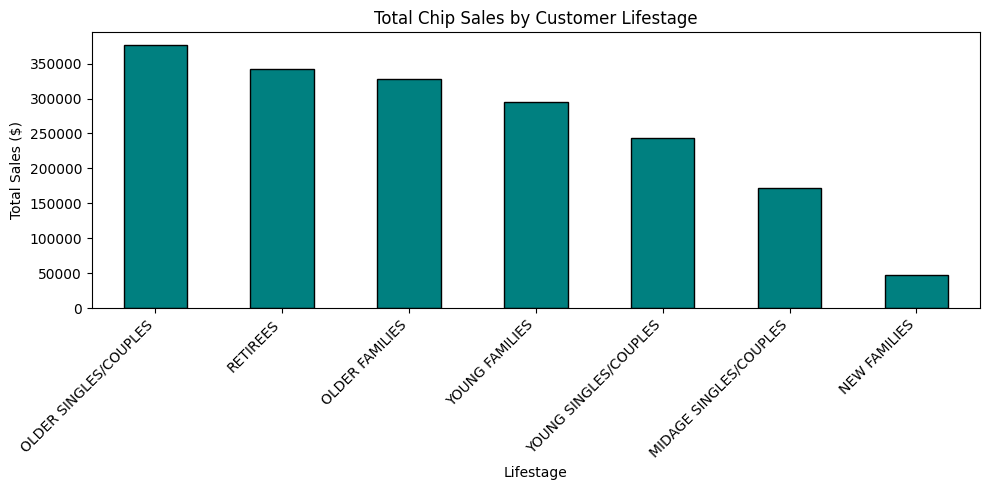

In [26]:
#Analysis 1 - Which segment spends the most overall?
segment_sales = merged.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)
print(segment_sales)

segment_sales.plot(kind='bar', color='teal', edgecolor='black', figsize=(10,5))
plt.title('Total Chip Sales by Customer Lifestage')
plt.ylabel('Total Sales ($)')
plt.xlabel('Lifestage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Total Chip Sales by Customer Lifestage
The chart above shows total chip sales broken down by customer lifestage.

PREMIUM_CUSTOMER
Mainstream    700865.40
Budget        631406.85
Premium       472905.45
Name: TOT_SALES, dtype: float64


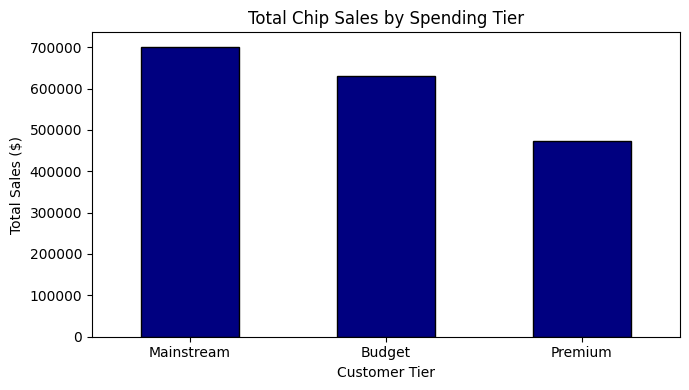

In [27]:
#Analysis 2 - Which spending tier spends the most?
tier_sales = merged.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False)
print(tier_sales)

tier_sales.plot(kind='bar', color='navy', edgecolor='black', figsize=(7,4))
plt.title('Total Chip Sales by Spending Tier')
plt.ylabel('Total Sales ($)')
plt.xlabel('Customer Tier')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Total Chip Sales by Spending Tier
The chart above compares total chip sales across Budget, Mainstream 
and Premium customer tiers.

PREMIUM_CUSTOMER           Budget  Mainstream    Premium
LIFESTAGE                                               
MIDAGE SINGLES/COUPLES   33345.70    84734.25   54443.85
NEW FAMILIES             20607.45    15979.70   10760.80
OLDER FAMILIES          156863.75    96413.55   75242.60
OLDER SINGLES/COUPLES   127833.60   124648.50  123537.55
RETIREES                105916.30   145168.95   91296.65
YOUNG FAMILIES          129717.95    86338.25   78571.70
YOUNG SINGLES/COUPLES    57122.10   147582.20   39052.30


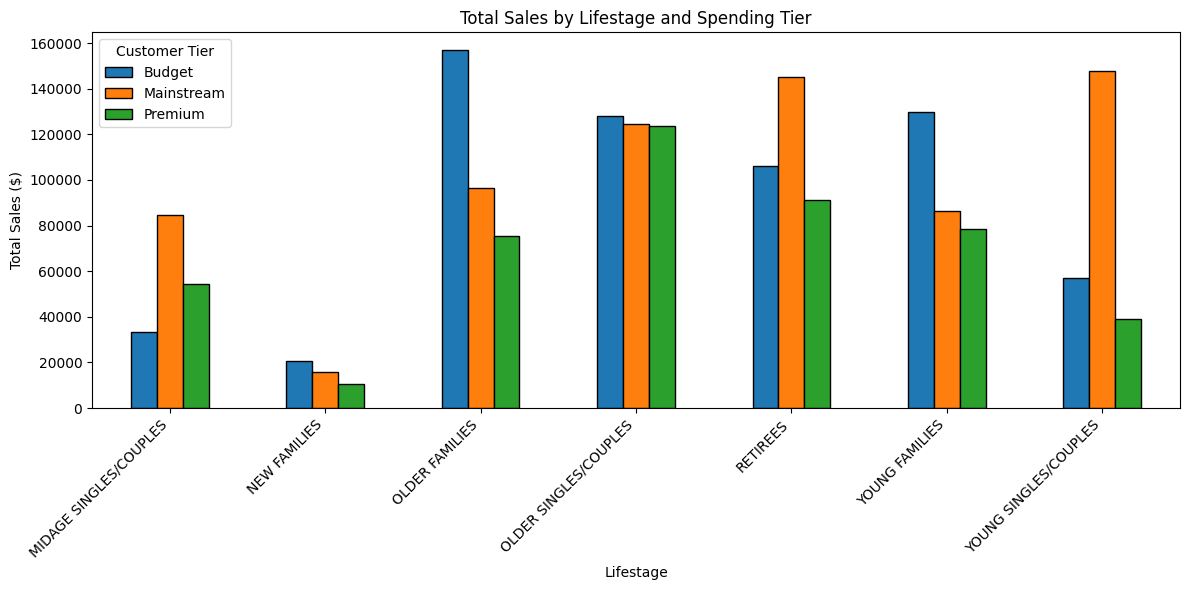

In [28]:
# Analysis 3 — Combined segment and tier
combined = merged.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
print(combined)

combined.plot(kind='bar', figsize=(12,6), edgecolor='black')
plt.title('Total Sales by Lifestage and Spending Tier')
plt.ylabel('Total Sales ($)')
plt.xlabel('Lifestage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Tier')
plt.tight_layout()
plt.show()

### Total Chip Sales by Lifestage and Spending Tier Combined
The chart above shows how sales are distributed across every 
combination of lifestage and spending tier.